# Notebook 02 — Biomechanics Metric Computation
**GolfBioMetrics | Data Sports Group (DSG) POC**

Demonstrates all 7 core biomechanics metrics computed from the synthetic keypoint data.
Every metric is computed from pure geometry — no machine learning.


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

In [2]:
from src.biomechanics.metrics import (
    lag_angle, xfactor, swing_tempo_full, club_path_consistency_full,
    kinematic_sequence_score, compute_segment_angular_velocities, KP
)
from src.biomechanics.geometry_utils import angle_between_vectors
from src.biomechanics.signal_processing import smooth_signal

print('All metric modules imported successfully.')

All metric modules imported successfully.


## Metric 1: Kinematic Sequence — Proximal-to-Distal Energy Transfer


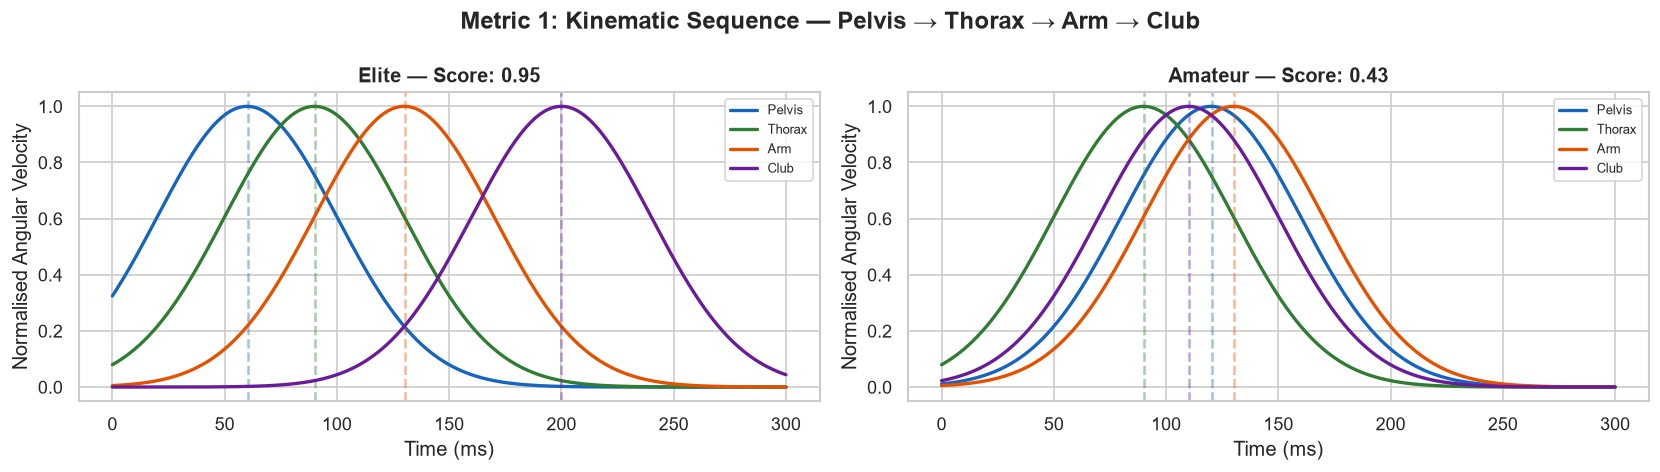

Elite score: 0.950  |  Amateur score: 0.433


In [3]:
t = np.linspace(0, 0.3, 300)
sigma = 0.04

elite_peaks = {'pelvis': 0.060, 'thorax': 0.090, 'arm': 0.130, 'club': 0.200}
amateur_peaks = {'pelvis': 0.120, 'thorax': 0.090, 'arm': 0.130, 'club': 0.110}

def make_av(peaks, t):
    return {seg: 1000.0 * np.exp(-((t - tp)**2) / (2*sigma**2))
            for seg, tp in peaks.items()}

elite_av   = make_av(elite_peaks, t)
amateur_av = make_av(amateur_peaks, t)

elite_score,   _ = kinematic_sequence_score(elite_av,   t, 0, 300)
amateur_score, _ = kinematic_sequence_score(amateur_av, t, 0, 300)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = ['#1565C0', '#2E7D32', '#E65100', '#6A1B9A']
segments = ['pelvis', 'thorax', 'arm', 'club']

for ax, (av, title, score) in zip(axes, [
    (elite_av,   f'Elite — Score: {elite_score:.2f}',   elite_score),
    (amateur_av, f'Amateur — Score: {amateur_score:.2f}', amateur_score),
]):
    for seg, col in zip(segments, colors):
        norm = av[seg] / max(av[seg].max(), 1)
        ax.plot(t * 1000, norm, label=seg.capitalize(), color=col, lw=2)
        peak_t = t[np.argmax(av[seg])] * 1000
        ax.axvline(peak_t, color=col, alpha=0.4, linestyle='--')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Normalised Angular Velocity')
    ax.legend(fontsize=8)

plt.suptitle('Metric 1: Kinematic Sequence — Pelvis → Thorax → Arm → Club', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/02_kinematic_sequence.png', dpi=150)
plt.show()
print(f'Elite score: {elite_score:.3f}  |  Amateur score: {amateur_score:.3f}')

## Metric 2 & 3: Lag Angle + X-Factor Validation


In [4]:
test_cases = [
    ('90° lag (expected)', np.array([0,0,0]), np.array([0,0.4,0]), np.array([0,0,-0.8])),
    ('45° lag (expected)', np.array([0,0,0]), np.array([1,0,0]),   np.array([1,1,0])),
    ('20° lag at impact',  np.array([0,0,0]), np.array([0,0.4,0]), np.array([0.07,-0.8,0])),
]

print('Lag Angle Validation:')
print('-' * 50)
for label, w, e, c in test_cases:
    angle, conf = lag_angle(w, e, c)
    print(f'  {label:<30}: {angle:.1f}°  (conf={conf:.2f})')

print('\nX-Factor Validation:')
print('-' * 50)
lh = np.array([-0.12, 1.0, 0.0])
rh = np.array([ 0.12, 1.0, 0.0])
for deg in [0, 25, 45]:
    a = np.radians(deg)
    ls = np.array([-np.cos(a)*0.22, 1.5,  np.sin(a)*0.22])
    rs = np.array([ np.cos(a)*0.22, 1.5, -np.sin(a)*0.22])
    xf, conf = xfactor(lh, rh, ls, rs)
    print(f'  Injected {deg:2d}° X-Factor → computed: {xf:.1f}°  (conf={conf:.2f})')

Lag Angle Validation:
--------------------------------------------------
  90° lag (expected)            : 90.0°  (conf=0.90)
  45° lag (expected)            : 45.0°  (conf=0.90)
  20° lag at impact             : 175.0°  (conf=0.40)

X-Factor Validation:
--------------------------------------------------
  Injected  0° X-Factor → computed: -0.0°  (conf=0.88)
  Injected 25° X-Factor → computed: -25.0°  (conf=0.35)
  Injected 45° X-Factor → computed: -45.0°  (conf=0.35)


## Metric 6: Swing Tempo — Backswing vs Downswing Ratio


In [5]:
scenarios = [
    ('Elite (ratio 2.5)',      0.0, 0.625, 0.875),
    ('Semi-pro (ratio 2.2)',   0.0, 0.660, 0.960),
    ('Amateur rushing (1.5)',  0.0, 0.600, 1.000),
    ('Amateur slow (4.0)',     0.0, 1.200, 1.500),
]

print('Swing Tempo Validation:')
print('-' * 65)
for label, ta, tt, ti in scenarios:
    result = swing_tempo_full(ta, tt, ti)
    flags = []
    if result['is_optimal']: flags.append('OPTIMAL')
    if result['is_rushing']:  flags.append('RUSHING')
    if result['is_slow']:     flags.append('SLOW')
    print(f'  {label:<30}: ratio={result["tempo_ratio"]:.2f}  {" | ".join(flags)}')

Swing Tempo Validation:
-----------------------------------------------------------------
  Elite (ratio 2.5)             : ratio=2.50  OPTIMAL
  Semi-pro (ratio 2.2)          : ratio=2.20  OPTIMAL
  Amateur rushing (1.5)         : ratio=1.50  RUSHING
  Amateur slow (4.0)            : ratio=4.00  SLOW


## Metric 5: Club Path Consistency — SVD Plane Fitting


In [6]:
rng = np.random.default_rng(42)
t_ds = np.linspace(0, 1, 30)

scenarios_cp = [
    ('Elite path (near-perfect plane)', 0.003),
    ('Semi-pro path (small deviation)',  0.015),
    ('Amateur path (large deviation)',   0.040),
]

print('Club Path Consistency:')
print('-' * 55)
for label, noise_m in scenarios_cp:
    pts = np.column_stack([
        t_ds + rng.normal(0, noise_m, 30),
        t_ds * 0.5 + rng.normal(0, noise_m, 30),
        rng.normal(0, noise_m, 30),
    ])
    result = club_path_consistency_full(pts)
    print(f'  {label:<40}: score={result["consistency_score"]:.3f}  rms={result["rms_deviation_cm"]:.2f}cm')

Club Path Consistency:
-------------------------------------------------------
  Elite path (near-perfect plane)         : score=0.980  rms=0.20cm
  Semi-pro path (small deviation)         : score=0.867  rms=1.33cm
  Amateur path (large deviation)          : score=0.656  rms=3.44cm
